#Daily Challenge — MNIST complet

Avant normalisation :
  x_train min=0, max=255
Après normalisation :
  x_train min=0.0, max=1.0
  x_train shape : (60000, 28, 28)
  x_test  shape : (10000, 28, 28)

Label original      : 5
Label one-hot       : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


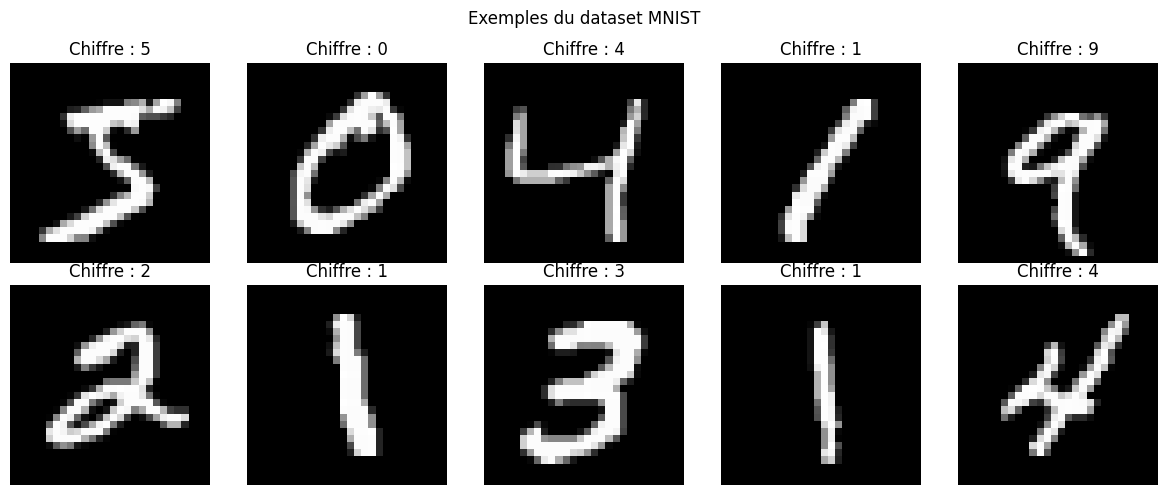

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


 Début de l'entraînement...

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9280 - loss: 0.2484 - val_accuracy: 0.9652 - val_loss: 0.1180
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9672 - loss: 0.1077 - val_accuracy: 0.9747 - val_loss: 0.0873
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9769 - loss: 0.0738 - val_accuracy: 0.9742 - val_loss: 0.0855
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9820 - loss: 0.0553 - val_accuracy: 0.9773 - val_loss: 0.0803
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9870 - loss: 0.0419 - val_accuracy: 0.9800 - val_loss: 0.0805
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9876 - loss: 0.0369 - val_accuracy: 0.9757 - val_loss: 0.0941
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9907 - loss: 0.0287 - val_accuracy: 0.9793 - val_loss: 0.0849
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accu

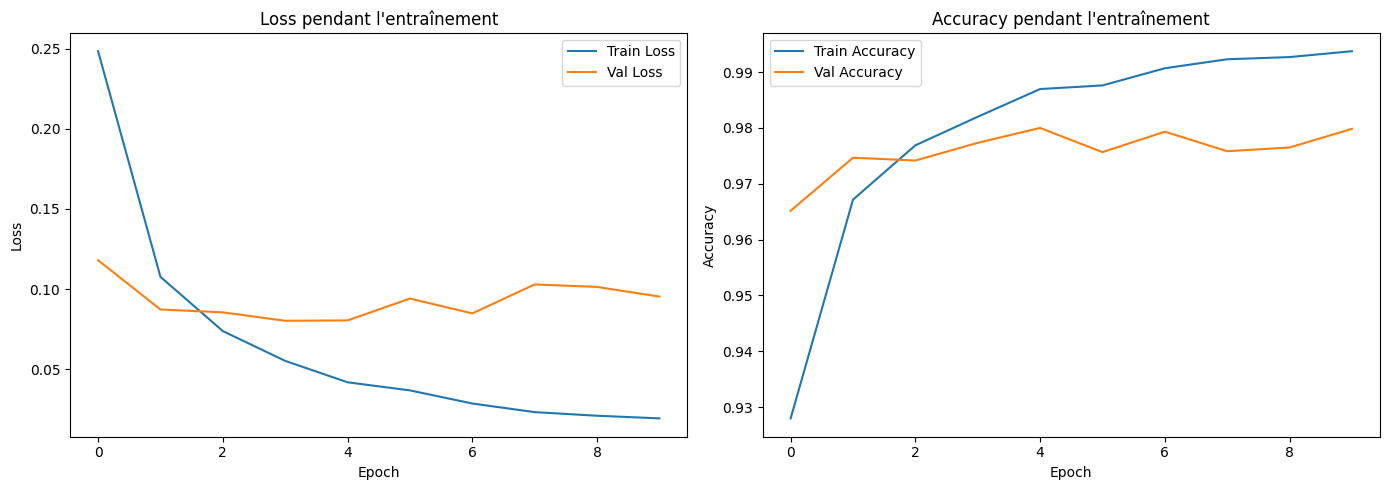


 Précision sur le test set : 97.91%
   Loss sur le test set      : 0.0872
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


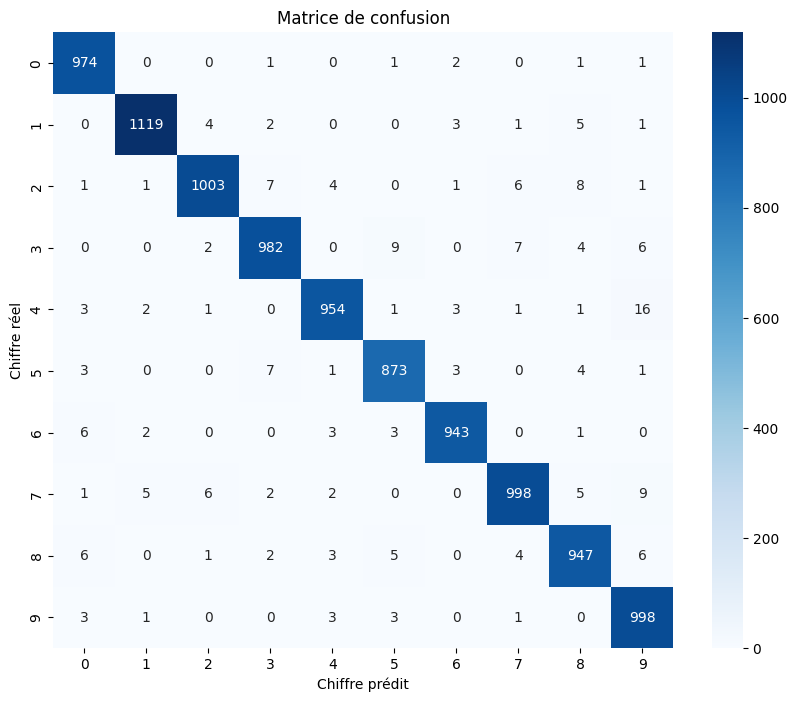


 Taux d'erreur par chiffre :
  Chiffre 7 : 2.9% d'erreurs  
  Chiffre 4 : 2.9% d'erreurs  
  Chiffre 2 : 2.8% d'erreurs  
  Chiffre 3 : 2.8% d'erreurs  
  Chiffre 8 : 2.8% d'erreurs  
  Chiffre 5 : 2.1% d'erreurs  
  Chiffre 6 : 1.6% d'erreurs  
  Chiffre 1 : 1.4% d'erreurs  
  Chiffre 9 : 1.1% d'erreurs  
  Chiffre 0 : 0.6% d'erreurs  


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ============================================================
# ÉTAPE 1 — Charger et préprocesser MNIST
# ============================================================

# Charger les données
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Avant normalisation :")
print(f"  x_train min={x_train.min()}, max={x_train.max()}")

# Normaliser (0 à 255) → (0 à 1)
x_train = x_train / 255.0
x_test  = x_test  / 255.0

print("Après normalisation :")
print(f"  x_train min={x_train.min()}, max={x_train.max()}")
print(f"  x_train shape : {x_train.shape}")  # (60000, 28, 28)
print(f"  x_test  shape : {x_test.shape}")   # (10000, 28, 28)

# One-Hot Encoding des labels
y_train_encoded = to_categorical(y_train, 10)
y_test_encoded  = to_categorical(y_test,  10)

print(f"\nLabel original      : {y_train[0]}")
print(f"Label one-hot       : {y_train_encoded[0]}")

# Afficher quelques images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f"Chiffre : {y_train[i]}")
    ax.axis('off')
plt.suptitle("Exemples du dataset MNIST")
plt.tight_layout()
plt.show()

# ============================================================
# ÉTAPE 2 — Construire le réseau de neurones
# ============================================================

model = models.Sequential([
    # Flatten : 28×28 → vecteur de 784 valeurs
    layers.Flatten(input_shape=(28, 28)),

    # Couche cachée 1 : 128 neurones, ReLU
    layers.Dense(128, activation='relu'),

    # Couche cachée 2 : 64 neurones, ReLU
    layers.Dense(64, activation='relu'),

    # Couche sortie : 10 neurones (0 à 9), Softmax
    layers.Dense(10, activation='softmax')
])

# Résumé de l'architecture
model.summary()

# Compiler le modèle
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================================
# ÉTAPE 3 — Entraîner le modèle
# ============================================================

print("\n Début de l'entraînement...\n")

history = model.fit(
    x_train, y_train_encoded,
    epochs=10,
    batch_size=32,
    validation_split=0.1,   # 10% pour valider pendant l'entraînement
    verbose=1
)

# Visualiser loss et accuracy pendant l'entraînement
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Courbe de Loss
ax1.plot(history.history['loss'],     label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss pendant l\'entraînement')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Courbe d'Accuracy
ax2.plot(history.history['accuracy'],     label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Accuracy pendant l\'entraînement')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

# ============================================================
# ÉTAPE 4 — Évaluer le modèle
# ============================================================

loss, accuracy = model.evaluate(x_test, y_test_encoded, verbose=0)
print(f"\n Précision sur le test set : {accuracy*100:.2f}%")
print(f"   Loss sur le test set      : {loss:.4f}")

# Prédictions
y_pred_probs  = model.predict(x_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)  # Classe prédite

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,      # Afficher les chiffres dans chaque case
    fmt='d',         # Format entier
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)
plt.title('Matrice de confusion')
plt.xlabel('Chiffre prédit')
plt.ylabel('Chiffre réel')
plt.show()

# Chiffres les plus difficiles à prédire
errors_per_digit = {}
for digit in range(10):
    mask = (y_test == digit)
    correct = np.sum(y_pred_labels[mask] == digit)
    total   = np.sum(mask)
    errors_per_digit[digit] = (total - correct) / total * 100

print("\n Taux d'erreur par chiffre :")
for digit, error_rate in sorted(errors_per_digit.items(),
                                 key=lambda x: x[1], reverse=True):
    bar = "" * int(error_rate)
    print(f"  Chiffre {digit} : {error_rate:.1f}% d'erreurs  {bar}")